# Rohban ORF pathway screen

{func}`~mantispy.ds.rohban` serves `cpg0017-rohban-pathways` {cite:p}`Rohban_2017`, an overexpression screen rather than a knockout or a small-molecule one. U2OS cells each overexpress one open reading frame, with roughly ten replicate wells per construct over five plates, so a hit is a gene whose gain of function moves the cells away from the control ORFs. The genes group into known signalling pathways, which is what makes it the pathway example.

In [1]:
import numpy as np
import pandas as pd
import plotly.express as px
import scanpy as sc

import mantispy as mt

In [2]:
import plotly.io as pio

pio.renderers.default = "notebook_connected"

In [3]:
adata = mt.ds.rohban()
adata

AnnData object with n_obs × n_vars = 1918 × 3616
    obs: 'Metadata_gene_name', 'Metadata_pert_name', 'Metadata_broad_sample', 'Metadata_cell_line', 'Metadata_ASSAY_WELL_ROLE', 'Metadata_GeneID', 'Metadata_Plate', 'Metadata_Well', 'Metadata_Site_Count', 'Metadata_Count_Cells', 'Metadata_Count_CellsIncludingEdges', 'Metadata_Count_Cytoplasm', 'Metadata_Count_Nuclei', 'Metadata_Count_NucleiIncludingEdges', 'Metadata_Object_Count', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Perturbation', 'Metadata_Perturbation_Type', 'Metadata_Gene', 'Metadata_Construct', 'Metadata_Allele'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## Constructs, genes and controls

`Metadata_Perturbation` is the ORF construct, the unit the screen varied, and several constructs can overexpress the same `Metadata_Gene`. `Metadata_Control` marks the control ORFs (Luciferase, LacZ and eGFP) that normalization reads against; the untreated `EMPTY` wells carry `Metadata_Perturbation == "untreated"` and are not flagged.

In [4]:
obs = adata.obs
pd.Series(
    {
        "wells": adata.n_obs,
        "constructs": obs["Metadata_Perturbation"].nunique(),
        "genes": obs["Metadata_Gene"].nunique(),
        "plates": obs["Metadata_Plate"].nunique(),
        "control wells": int(obs["Metadata_Control"].sum()),
    }
)

wells            1918
constructs        327
genes             194
plates              5
control wells     120
dtype: int64

## Cell count across the five plates

Overexpression changes proliferation, which cell count picks up plate by plate.

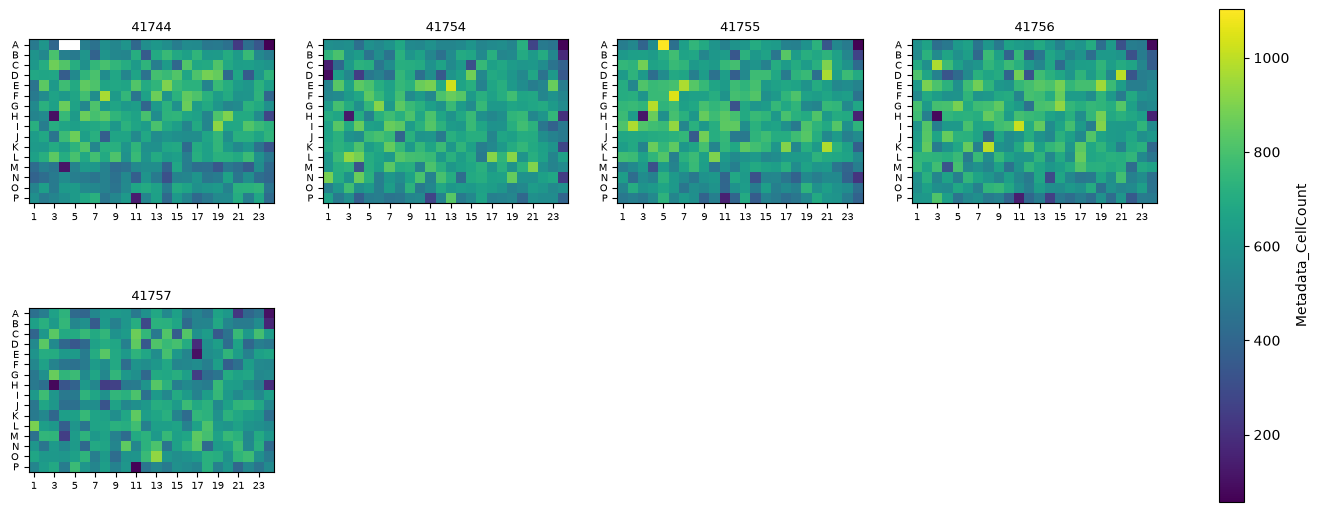

In [5]:
_ = mt.pl.plate(adata, color="Metadata_CellCount")

## Genes in profile space

The gene-level consensus (one `modz` profile per gene) placed on its first two principal components shows the spread the pathways sit in. Each point is a gene, sized by how many replicate wells backed its consensus.

In [6]:
genes = mt.ds.rohban(aggregated=True)
scaled = genes.copy()
sc.pp.scale(scaled)
scaled.X = np.nan_to_num(scaled.X)
sc.pp.pca(scaled, n_comps=10)
coords = pd.DataFrame(scaled.obsm["X_pca"][:, :2], columns=["PC1", "PC2"])
coords["gene"] = genes.obs["Metadata_Gene"].to_numpy()
coords["replicates"] = genes.obs["Metadata_ReplicateCount"].to_numpy()
fig = px.scatter(
    coords,
    x="PC1",
    y="PC2",
    color="replicates",
    hover_name="gene",
    title="Rohban genes in profile space",
)
fig.show()